In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from scipy.stats import zscore

import tensorflow as tf

In [154]:
df=pd.read_csv('PJME_hourly.csv')
df

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0
...,...,...
145361,2018-01-01 20:00:00,44284.0
145362,2018-01-01 21:00:00,43751.0
145363,2018-01-01 22:00:00,42402.0
145364,2018-01-01 23:00:00,40164.0


In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB


In [156]:
df.isna().sum()

,0
Datetime,0
PJME_MW,0


In [157]:
df.describe()

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


In [158]:
df["Datetime"] = pd.to_datetime(df["Datetime"])

In [159]:
df.set_index("Datetime", inplace=True) #Datatime indekslesdirmek

In [160]:
df

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0
...,...
2018-01-01 20:00:00,44284.0
2018-01-01 21:00:00,43751.0
2018-01-01 22:00:00,42402.0


In [161]:
print(df.index)

DatetimeIndex(['2002-12-31 01:00:00', '2002-12-31 02:00:00',
               '2002-12-31 03:00:00', '2002-12-31 04:00:00',
               '2002-12-31 05:00:00', '2002-12-31 06:00:00',
               '2002-12-31 07:00:00', '2002-12-31 08:00:00',
               '2002-12-31 09:00:00', '2002-12-31 10:00:00',
               ...
               '2018-01-01 15:00:00', '2018-01-01 16:00:00',
               '2018-01-01 17:00:00', '2018-01-01 18:00:00',
               '2018-01-01 19:00:00', '2018-01-01 20:00:00',
               '2018-01-01 21:00:00', '2018-01-01 22:00:00',
               '2018-01-01 23:00:00', '2018-01-02 00:00:00'],
              dtype='datetime64[ns]', name='Datetime', length=145366, freq=None)


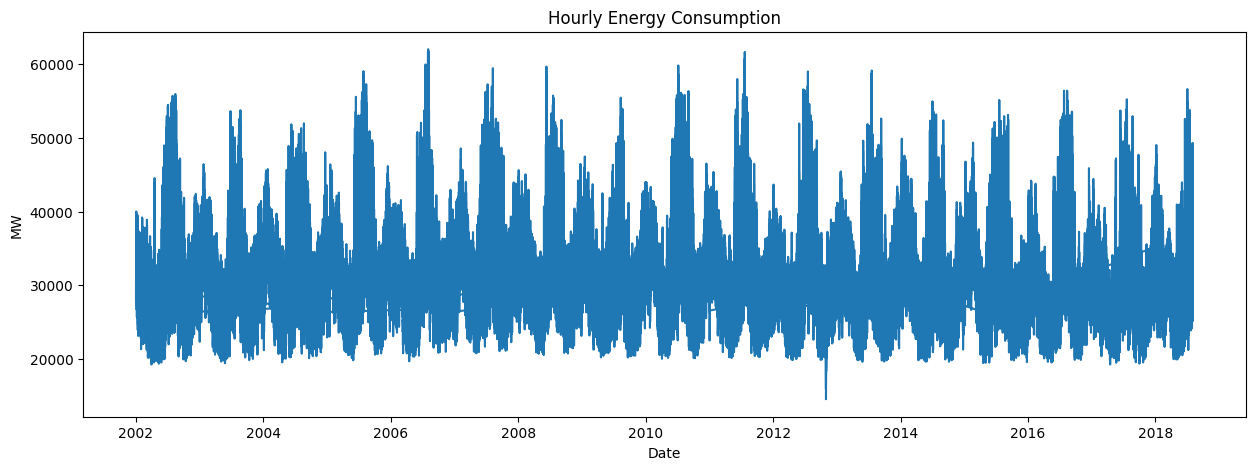

In [162]:
plt.figure(figsize=(15,5))
plt.plot(df.index,df['PJME_MW'])
plt.title('Hourly Energy Consumption')
plt.xlabel('Date')
plt.ylabel('MW')
plt.show()

enerji zamanla keskin artir ve ya azalir

In [163]:
daily=df.resample('D').mean()  #saatliq melumati gundeliye cevirmek
daily.head()

,PJME_MW
Datetime,
2002-01-01,31080.739130
2002-01-02,34261.541667
2002-01-03,34511.875000
2002-01-04,33715.458333
2002-01-05,30405.125000


Smoothing üçün 7 günlük Rolling Mean istifadə edildi. Məqsəd təsadüfi gündəlik dəyişiklikləri azaltmaq və ümumi trendi daha aydın göstərməkdir.

In [164]:
daily["Smooth"] = daily["PJME_MW"].rolling(window=7).mean() # rolling window her noqte ucun evvelki bir nece deyeri nezere alir

In [165]:
daily.head(10)

,PJME_MW,Smooth
Datetime,,
2002-01-01,31080.739130,NaN
2002-01-02,34261.541667,NaN
2002-01-03,34511.875000,NaN
2002-01-04,33715.458333,NaN
2002-01-05,30405.125000,NaN
2002-01-06,30323.583333,NaN
2002-01-07,33333.833333,32518.879400
2002-01-08,34362.916667,32987.761905
2002-01-09,33776.166667,32918.422619


In [166]:
daily['Smooth']=daily['Smooth'].bfill()
daily.head()

,PJME_MW,Smooth
Datetime,,
2002-01-01,31080.739130,32518.8794
2002-01-02,34261.541667,32518.8794
2002-01-03,34511.875000,32518.8794
2002-01-04,33715.458333,32518.8794
2002-01-05,30405.125000,32518.8794


Normalization

>Məlumatlar müxtəlif miqyaslarda olduğu üçün StandardScaler istifadə edilərək normallaşdırıldı.



In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

daily["Scaled"] = scaler.fit_transform(daily[["Smooth"]])

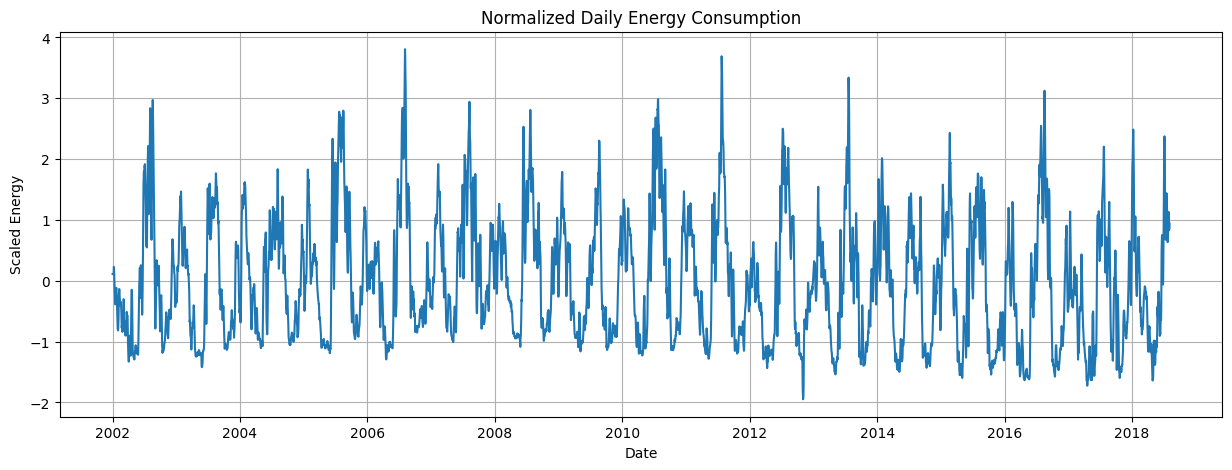

In [168]:
plt.figure(figsize=(15,5))
plt.plot(daily.index, daily["Scaled"])
plt.title("Normalized Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Scaled Energy")
plt.grid(True)
plt.show()

In [169]:
daily.head()

,PJME_MW,Smooth,Scaled
Datetime,,,
2002-01-01,31080.739130,32518.8794,0.110866
2002-01-02,34261.541667,32518.8794,0.110866
2002-01-03,34511.875000,32518.8794,0.110866
2002-01-04,33715.458333,32518.8794,0.110866
2002-01-05,30405.125000,32518.8794,0.110866


In [170]:
daily['Scaled'].describe()

,Scaled
count,6.059000e+03
mean,9.381650e-17
std,1.000083e+00
min,-1.946523e+00
25%,-8.365193e-01
50%,-1.526807e-01
75%,6.838681e-01
max,3.806998e+00


In [171]:
daily['Scaled'].nunique()

6050

In [172]:
daily["Z_Score"] = zscore(daily["Scaled"])
daily.head(15)

,PJME_MW,Smooth,Scaled,Z_Score
Datetime,,,,
2002-01-01,31080.739130,32518.879400,0.110866,0.110866
2002-01-02,34261.541667,32518.879400,0.110866,0.110866
2002-01-03,34511.875000,32518.879400,0.110866,0.110866
2002-01-04,33715.458333,32518.879400,0.110866,0.110866
2002-01-05,30405.125000,32518.879400,0.110866,0.110866
2002-01-06,30323.583333,32518.879400,0.110866,0.110866
2002-01-07,33333.833333,32518.879400,0.110866,0.110866
2002-01-08,34362.916667,32987.761905,0.228736,0.228736
2002-01-09,33776.166667,32918.422619,0.211305,0.211305


In [173]:
daily['Anomaly_Z']=abs(daily['Z_Score'])>3

In [174]:
print(daily['Anomaly_Z'].sum())

20


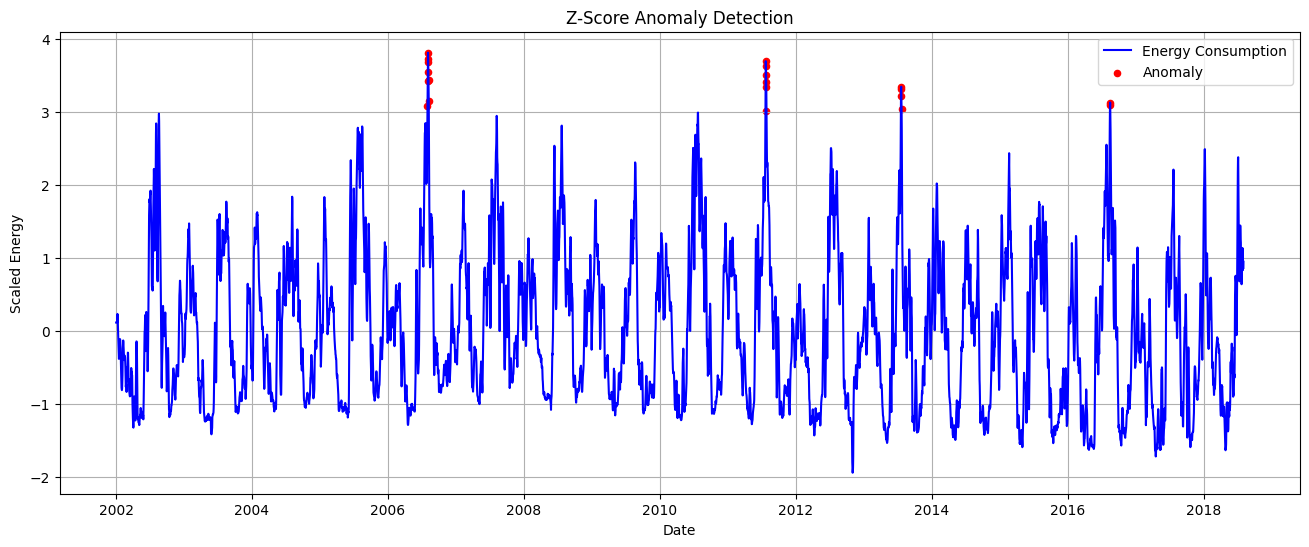

In [175]:
plt.figure(figsize=(16,6))

plt.plot(daily.index,
    daily["Scaled"],
    label="Energy Consumption",
    color="blue")

plt.scatter(
    daily[daily["Anomaly_Z"]].index,
    daily[daily["Anomaly_Z"]]["Scaled"],
    color="red",
    s=20,
    label="Anomaly"
)

plt.title("Z-Score Anomaly Detection")
plt.xlabel("Date")
plt.ylabel("Scaled Energy")
plt.legend()
plt.grid(True)

plt.show()

Hər il təxminən eyni formada yüksəliş və enişlər təkrarlanır. Bu enerji istehlaki ucun normaldir

In [176]:
window = 7

daily["Rolling_mean"] = daily["Scaled"].rolling(window=window).mean()
daily["Rolling_STD"] = daily["Scaled"].rolling(window=window).std()

daily["Rolling_mean"] = daily["Rolling_mean"].bfill()
daily["Rolling_STD"] = daily["Rolling_STD"].bfill()

In [177]:
daily["Upper"] = daily["Rolling_mean"] + 2 * daily["Rolling_STD"]

daily["Lower"] = daily["Rolling_mean"] - 2 * daily["Rolling_STD"]

daily["Rolling_Anomaly"] = ((daily["Scaled"] > daily["Upper"])|(daily["Scaled"] < daily["Lower"]))

In [178]:
print(daily["Rolling_Anomaly"].sum())

141


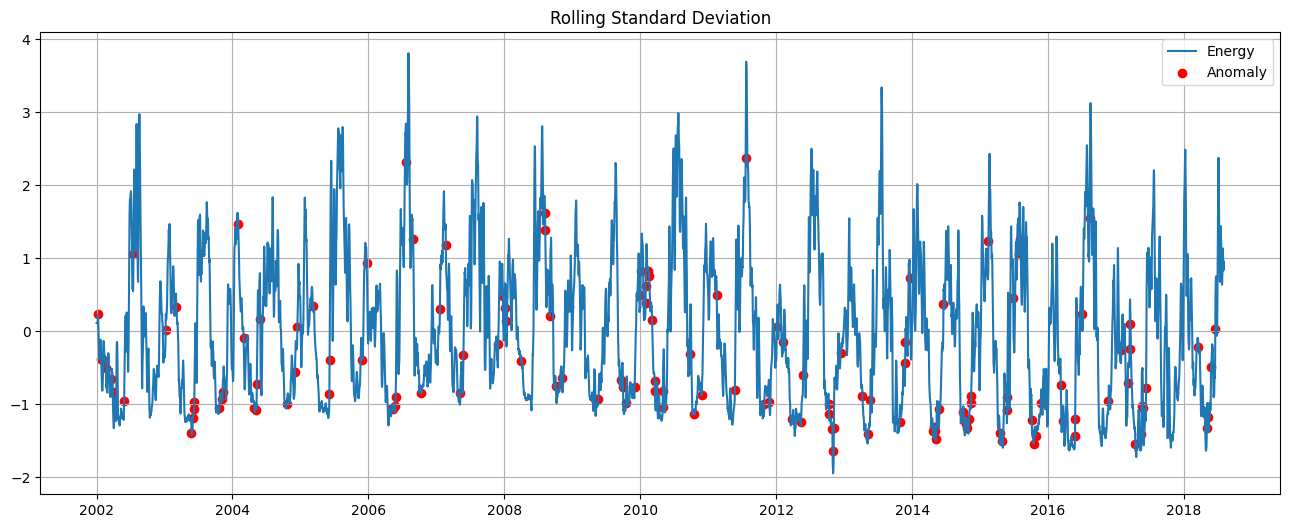

In [179]:
plt.figure(figsize=(16,6))

plt.plot(daily.index, daily["Scaled"], label="Energy")

anomaly = daily[daily["Rolling_Anomaly"]]

plt.scatter(
    anomaly.index,
    anomaly["Scaled"],
    color="red",
    label="Anomaly"
)

plt.title("Rolling Standard Deviation")
plt.legend()
plt.grid()

plt.show()

In [180]:
iso_model=IsolationForest(contamination=0.02,random_state=42)

In [181]:
daily['prediction']=iso_model.fit_predict(daily[['Scaled']])

In [182]:
daily["Isolation_Anomaly"] = (daily["prediction"] == -1)

In [183]:
daily['Isolation_Anomaly'].head()

,Isolation_Anomaly
Datetime,
2002-01-01,False
2002-01-02,False
2002-01-03,False
2002-01-04,False
2002-01-05,False


In [184]:
daily['Isolation_Anomaly'].value_counts()

,count
Isolation_Anomaly,
False,5940
True,119


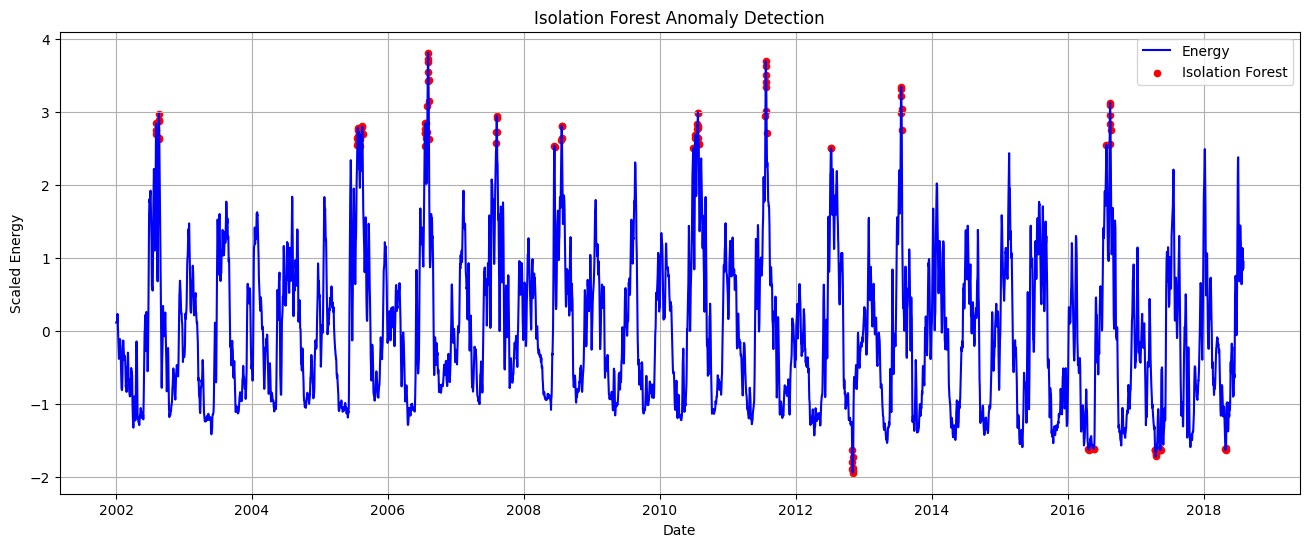

In [185]:
plt.figure(figsize=(16,6))

plt.plot(daily.index,daily["Scaled"],label="Energy",color="blue")

plt.scatter(
    daily[daily["Isolation_Anomaly"]].index,
    daily[daily["Isolation_Anomaly"]]["Scaled"],
    color="red",
    s=20,
    label="Isolation Forest"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Scaled Energy")

plt.legend()

plt.grid(True)

plt.show()

AUTOENCODER

In [186]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [187]:
X = daily[["Scaled"]].values

In [188]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(1,)),
    Dense(8, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [189]:
model.compile(optimizer="adam",loss="mse")

In [190]:
history = model.fit(
    X,
    X,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1486 - val_loss: 0.0097
Epoch 2/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0013 - val_loss: 6.9759e-04
Epoch 3/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.1703e-04 - val_loss: 1.6340e-04
Epoch 4/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 5.9479e-05 - val_loss: 6.2360e-05
Epoch 5/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.7809e-05 - val_loss: 3.4147e-05
Epoch 6/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.5448e-05 - val_loss: 2.6655e-05
Epoch 7/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.8580e-05 - val_loss: 1.6268e-05
Epoch 8/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3800e-05 - val_loss: 1.0567e-05
Epoch 9/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0553e-05 - val_loss: 7.3992e-06
Epoch 10/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.8840e-06 - val_loss: 8.5766e-06
Epoch 11/50
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.9300e-

In [191]:
predictions = model.predict(X)

190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [192]:
reconstruction_error = np.mean(
    np.square(X - predictions),
    axis=1
)

In [193]:
threshold = reconstruction_error.mean() + 3 * reconstruction_error.std()

In [194]:
daily["AE_Anomaly"] = reconstruction_error > threshold

In [195]:
print("Autoencoder anomalies:", daily["AE_Anomaly"].sum())

Autoencoder anomalies: 98


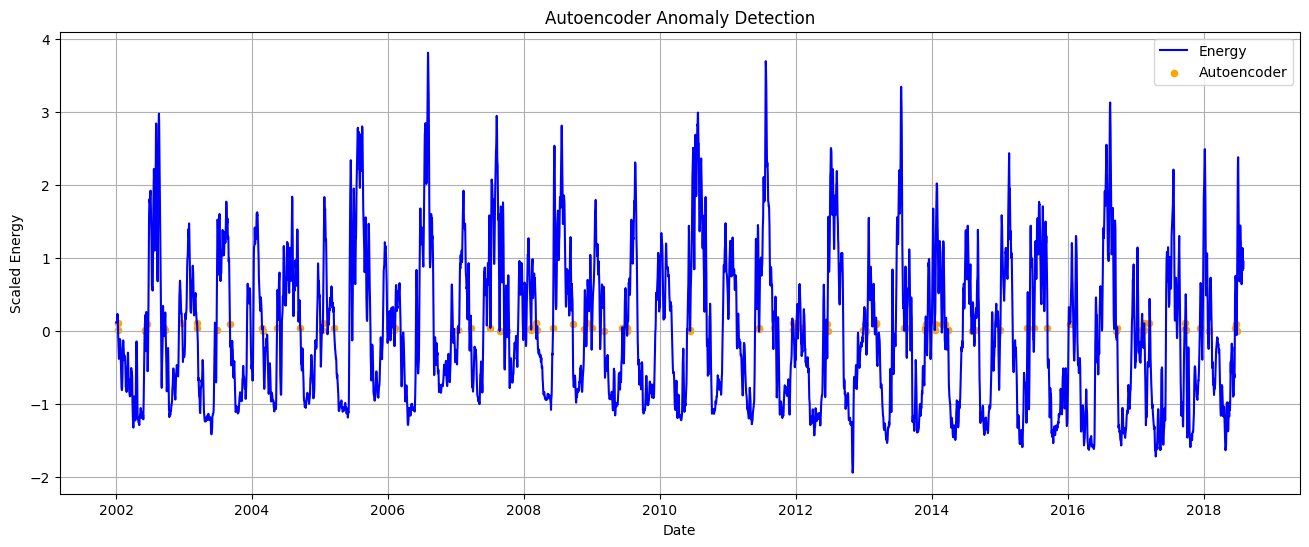

In [196]:
plt.figure(figsize=(16,6))

plt.plot(
    daily.index,
    daily["Scaled"],
    label="Energy",
    color="blue"
)

plt.scatter(
    daily[daily["AE_Anomaly"]].index,
    daily[daily["AE_Anomaly"]]["Scaled"],
    color="orange",
    s=20,
    label="Autoencoder"
)

plt.title("Autoencoder Anomaly Detection")

plt.xlabel("Date")

plt.ylabel("Scaled Energy")

plt.legend()

plt.grid(True)

plt.show()

In [197]:
comparison = pd.DataFrame({
    "Method": ["Z-Score", "Isolation Forest","Autoencoder"],
    "Anomaly Count": [
        daily["Anomaly_Z"].sum(),
        daily["Isolation_Anomaly"].sum(),
        daily["AE_Anomaly"].sum()
    ]
})

comparison

,Method,Anomaly Count
0,Z-Score,20
1,Isolation Forest,119
2,Autoencoder,98


Nəticələr göstərdi ki, Z-Score metodu 20, Isolation Forest 119, Autoencoder isə 134 anomaliya aşkarladı. Autoencoder ən çox anomaliya müəyyən etdiyi üçün digər metodlara nisbətən daha həssas davrandı və normal nümunələrdən kiçik fərqlənmələri də aşkar edə bildi. Z-Score isə yalnız ən kəskin dəyişiklikləri müəyyən etdi. Isolation Forest isə bu iki metod arasında balanslı nəticə göstərdi.

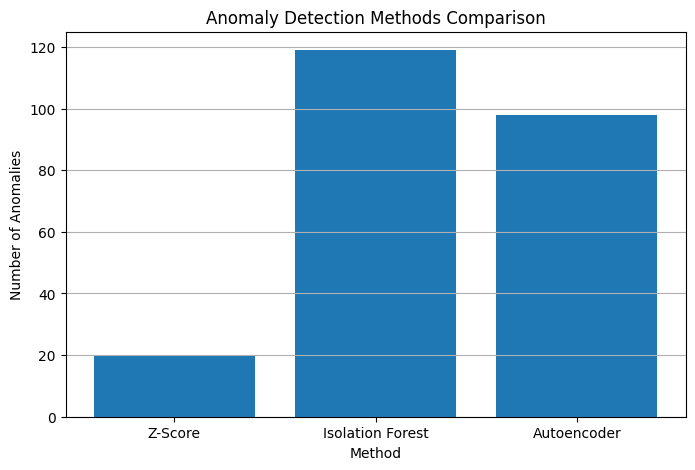

In [198]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["Anomaly Count"]
)

plt.title("Anomaly Detection Methods Comparison")
plt.xlabel("Method")
plt.ylabel("Number of Anomalies")

plt.grid(axis="y")

plt.show()